In [12]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import scipy
from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq

plt.style.use('matlab.mplstyle')

In [13]:
UR = np.genfromtxt(r'C:\Users\z003zh2j\Desktop\PLOT\eqn\hyur.csv', delimiter=',', skip_header=1)

t = UR[: , 0]/1e6
u = UR[: , 1]/30
msb = UR[: , 2]/1e3

In [14]:
ABR = np.genfromtxt(r'C:\Users\z003zh2j\Desktop\PLOT\eqn\hyab.csv', delimiter=',', skip_header=1)

tt = ABR[: , 0]/1e6
a = ABR[: , 1]/1e3
b = ABR[: , 2]/1e3

In [15]:
d_msb = np.diff(msb)
prah = -2
indexy_poklesu = np.where(d_msb < prah)[0]

if indexy_poklesu.size == 0:
    R = 50

R = indexy_poklesu[0]*350e-6
print(R)

def timel(leng,okno,jaky):
    if jaky == "R":
        jaky = R

    N1 = np.linspace(jaky-(-1 * ((leng-1) /2)) * okno , jaky-((leng-1) /2)* okno,leng)
    N2 = np.linspace(-1 * ((leng-1) /2) * okno , ((leng-1) /2) * okno,leng)
    N1 = N1.tolist()
    N1.sort()
    N2 = N2.tolist()
    N2 = ["%.2f" % member for member in N2]

    return(N1,N2)

59.59135


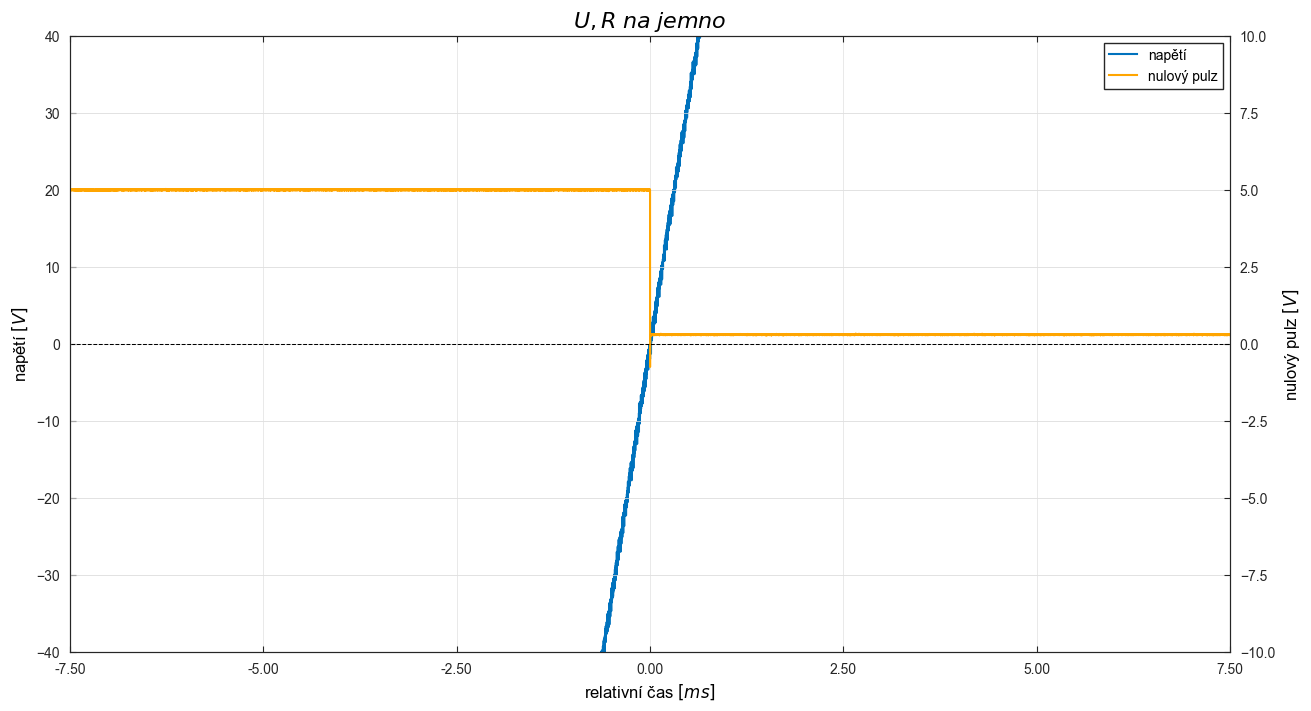

In [16]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax2 = host.twinx()
ax = plt.gca()
    
host.set_xlim(R-7.5, R+7.5)
host.set_ylim(-40, 40)
ax2.set_ylim(-10, 10)

p1 = host.plot(t, u, label="napětí")
p2 = ax2.plot(t, msb, label="nulový pulz", color='orange')
# ax2.set_yticks(np.arange(-0.5, 0.5+0.5/4, step=0.5/4))
plt.hlines(0,0,t[-1],color = 'k', linestyles='--',lw = 0.75)
plt.title("$U,R$ $na$ $jemno$", fontsize=16, color='k')
host.legend(handles=p1+p2, loc='upper right')
host.set_yticks(np.arange(-40, 50, step=10))
host.yaxis.label.set_color(p1[0].get_color())
ax2.yaxis.label.set_color(p2[0].get_color())


# ax.set_xticks([R,R-0.2,R+0.2,R-0.4,R+0.4,R-0.6,R+0.6]) 
# ax.set_xticklabels(['0',"-0.2","0.2","-0.4","0.4","-0.6","0.6"])
N1 , N2 = timel(7,2.5,"R")
ax.set_xticks(N1) 
ax.set_xticklabels(N2)
host.set_xlabel("relativní čas $[ms]$", fontsize=12, color = 'k')
host.set_ylabel("napětí $[V]$", fontsize=12, color = 'k')
ax2.set_ylabel("nulový pulz $[V]$", fontsize=12, color = 'k')
plt.show()

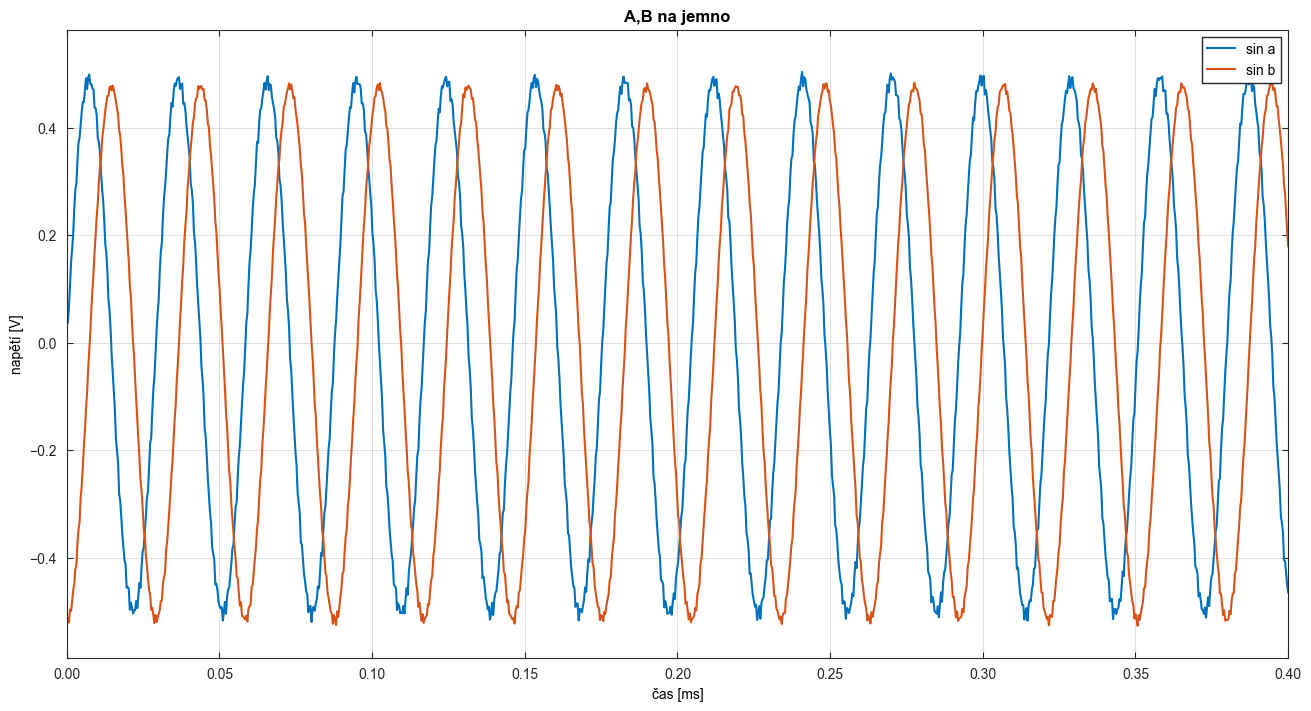

In [17]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax = plt.gca()
plt.title("A,B na jemno")
p1 = plt.plot(tt,a, label="sin a")
p2 = plt.plot(tt,b, label="sin b")
plt.xlim(0,0.4)
host.set_xlabel("čas [ms]")
host.set_ylabel("napětí [V]")
host.legend(handles=p1+p2, loc='upper right')
plt.grid(color='lightgrey', linestyle='-', linewidth=0.5)
# # plt.show()
# ax.set_xticks([RR,RR-0.2,RR+0.2,RR-0.1,RR+0.1])#,RR-0.4,RR+0.4,RR-0.6,RR+0.6]) 
# ax.set_xticklabels(['0',"-0.2","0.2","-0.1","0.1"])#,"-0.4","+0.4","-0.6","+0.6"])
# ax.set_xticks(N1) 
# ax.set_xticklabels(N2)

plt.show()

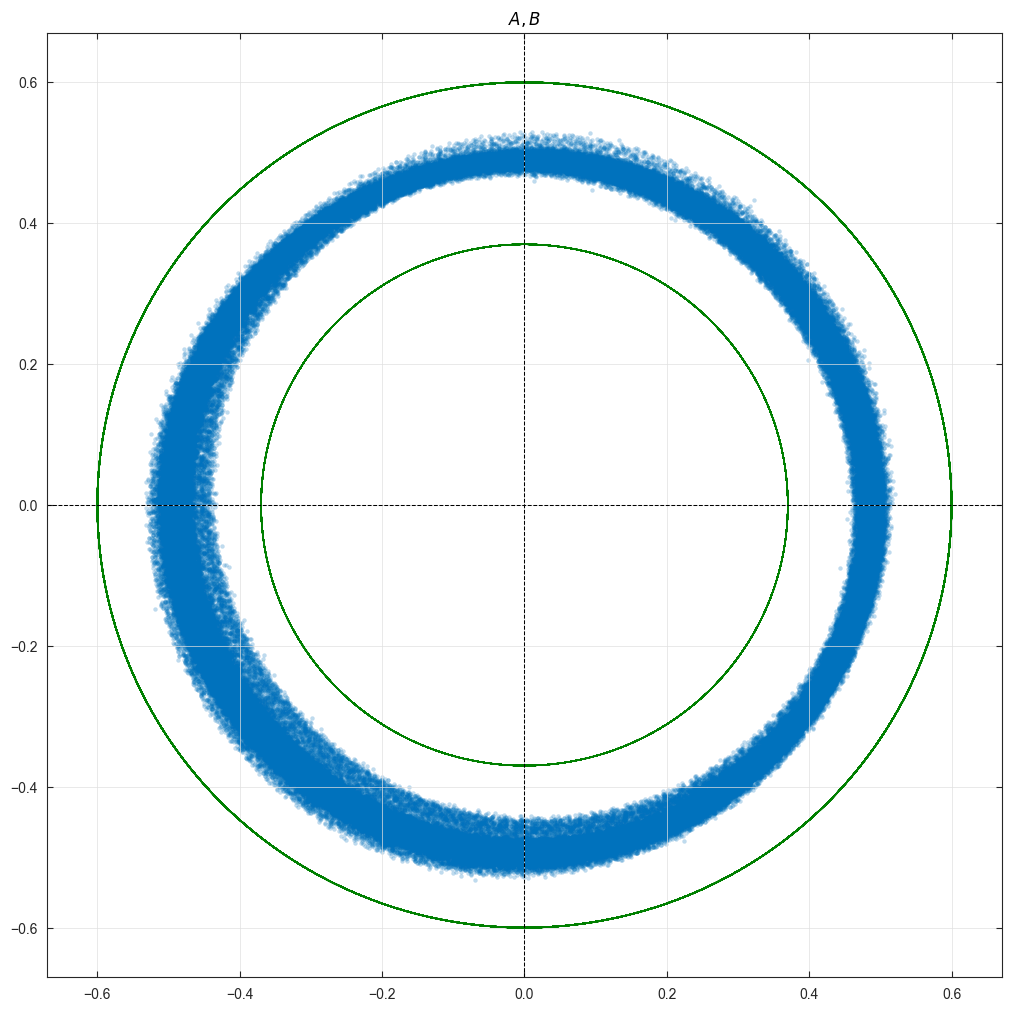

In [18]:
x = np.linspace(0,1000,10000)
y = 0.6 *np.sin(1*x+0)+0
yy = 0.6 *np.sin(1*x+np.pi/2)+0
w = 0.37 *np.sin(1*x+0)+0
ww = 0.37 *np.sin(1*x+np.pi/2)+0
fig = plt.subplots(figsize=(10,10), layout='constrained')
plt.title("$A,B$")
plt.plot(y,yy, lw = 0.75,color = 'g')
plt.plot(w,ww, lw = 0.75,color = 'g')
# plt.scatter(a,b, linewidths= 0.1, marker=".", alpha=0.005)
plt.scatter(a[0:len(a)//6],b[0:len(b)//6], linewidths= 0.1, marker=".", alpha=0.25)
plt.xlim(-0.67,0.67)
plt.ylim(-0.67,0.67)
plt.vlines(0,-0.67,0.67,color = 'k', linestyles='--',lw = 0.75)
plt.hlines(0,-0.67,0.67,color = 'k', linestyles='--',lw = 0.75)
plt.show()

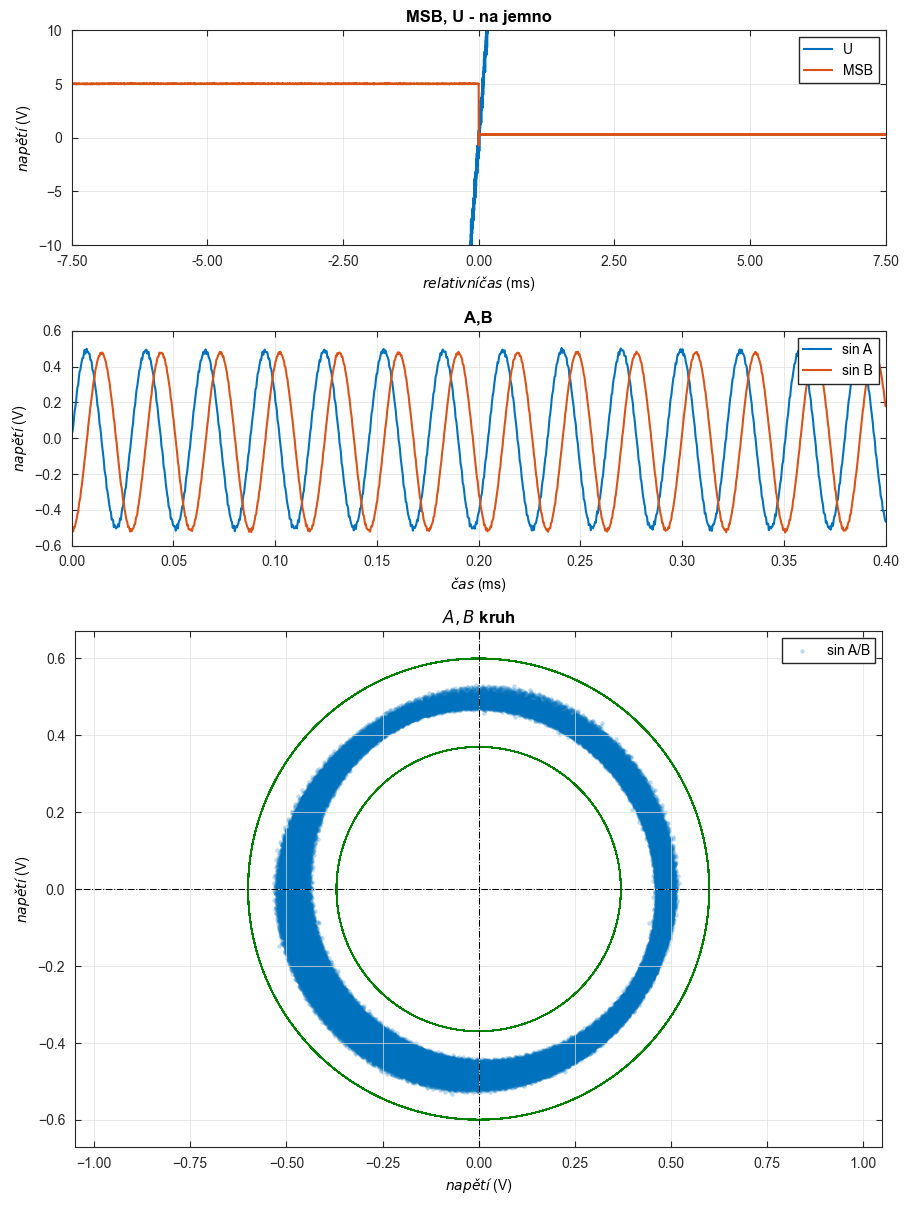

In [24]:
fig = plt.figure(figsize=(10.5, 14.5))

# Vytvoření mřížky (4 řádků, 1 sloupec)
gs = fig.add_gridspec(4, 1, hspace=0.4, wspace=0.3)

# 1. Horní graf - zabere 1. řádek (index 0)
ax1 = fig.add_subplot(gs[0, 0])
N1 , N2 = timel(7,2.5,"R")
ax1.set_xticks(N1) 
ax1.set_xticklabels(N2)
ax1.plot(t, u, label="U")
ax1.plot(t, msb, label="MSB")
ax1.set_xlim(R-7.5, R+7.5)
ax1.set_ylim(-10, 10)
ax1.set_title('MSB, U - na jemno')
ax1.legend(loc='upper right')
ax1.set_xlabel("$relativní čas$ (ms)")
ax1.set_ylabel("$napětí$ (V)")

# 2. Prostřední graf - zabere 2. řádek (index 1)
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_xlim(0,0.4)
ax2.set_ylim(-0.6, 0.6)
ax2.plot(tt, a, label="sin A")
ax2.plot(tt, b, label="sin B")
ax2.set_title("A,B")
ax2.legend(loc='upper right')
ax2.set_xlabel("$čas$ (ms)")
ax2.set_ylabel("$napětí$ (V)")

# 3. Velký spodní graf - zabere zbývající 3 řádky (indexy 2 až 4)
# V Pythonu se to zapisuje pomocí řezu (slice) [2:5] neboli od indexu 2 včetně do 5 (vyjma)
ax3 = fig.add_subplot(gs[2:4, 0])
x = np.linspace(0,1000,10000)
y = 0.6 *np.sin(1*x+0)+0
yy = 0.6 *np.sin(1*x+np.pi/2)+0
w = 0.37 *np.sin(1*x+0)+0
ww = 0.37 *np.sin(1*x+np.pi/2)+0
ax3.plot(y, yy, lw=0.75, color='g')
ax3.plot(w, ww, lw=0.75, color='g')
ax3.scatter(a[0:len(a)//6], b[0:len(b)//6], linewidths=0.1, marker=".", alpha=0.25, label="sin A/B")

#ax3.set_xlim(-0.67, 0.67)
ax3.set_xlim(-1.05, 1.05)
ax3.set_ylim(-0.67, 0.67)
ax3.vlines(0, -0.67, 0.67, color='k', linestyles='-.', lw=0.75)
ax3.hlines(0, -1.2, 1.2, color='k', linestyles='-.', lw=0.75)
ax3.set_title("$A,B$ kruh")
ax3.legend(loc='upper right')
ax3.set_xlabel("$napětí$ (V)")
ax3.set_ylabel("$napětí$ (V)")
ax3.set_aspect('equal', adjustable='box')

# # Zobrazení grafu
plt.show()